#### Explainable Credit Risk Assessment

##### 1. Load the Data
We will bring in the loan applicant data.

This data has details like income, age, and loan amount.

It also tells us who repaid and who defaulted.

In [1]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


#### 2. Exploratory Data Analysis (EDA)

Here we simply look at the data before touching it.

We want to understand it first, then work on it.

#### Basic info about the data

Check how many rows and columns we have.

Check the data type of each column.

In [3]:
df.shape
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [4]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

#### Target balance

Check how many people defaulted vs how many repaid.

This tells us if our data is balanced or imbalanced.

In [5]:
df.head()
df['loan_status'].unique()
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

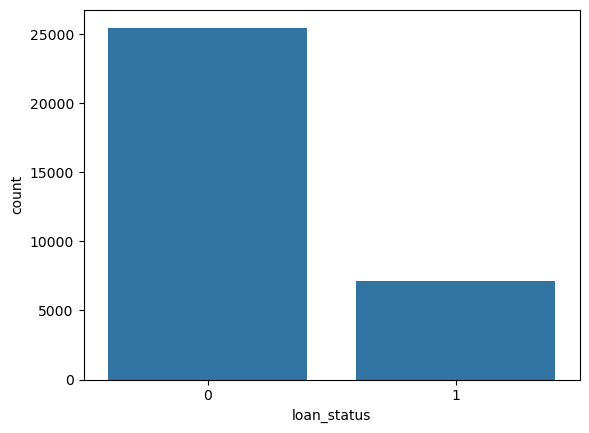

In [6]:
sns.countplot(x='loan_status',data=df)
plt.show()

Outlier check

Look for values that seem impossible, like age 144.

These are signs of bad data entries.

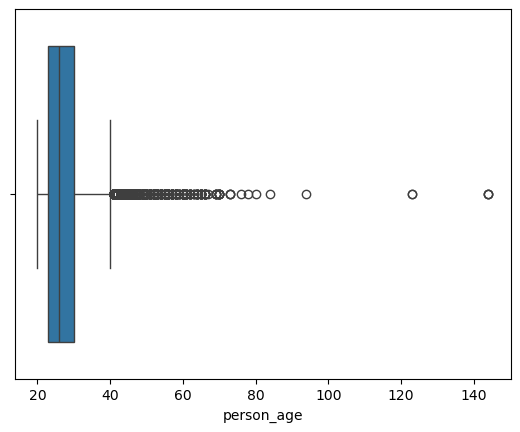

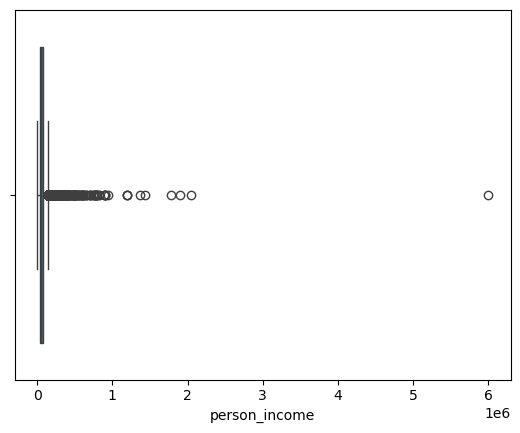

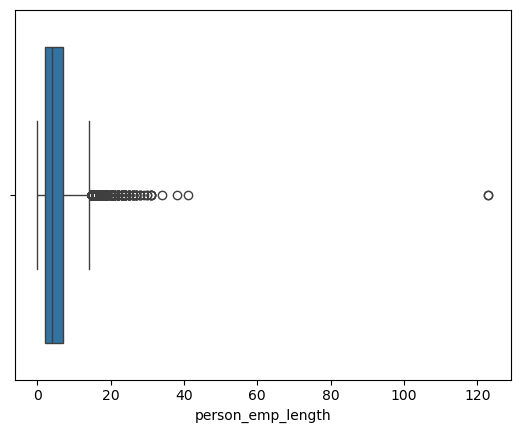

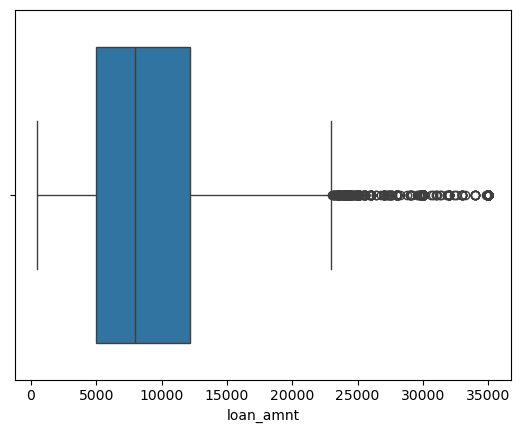

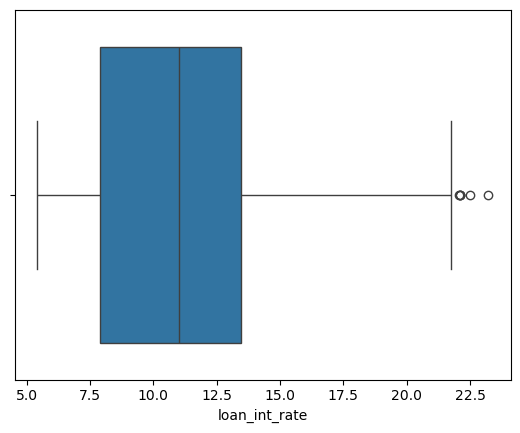

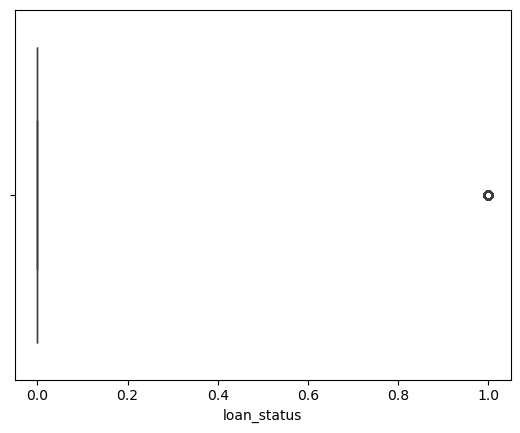

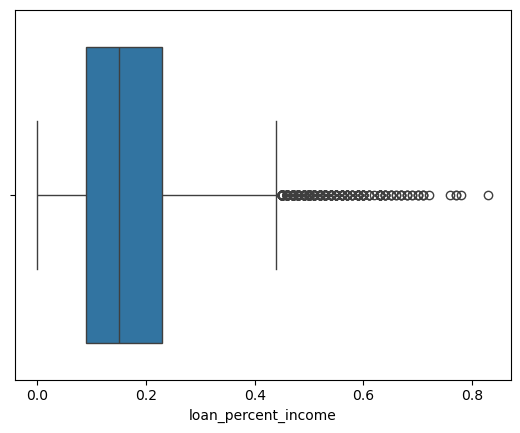

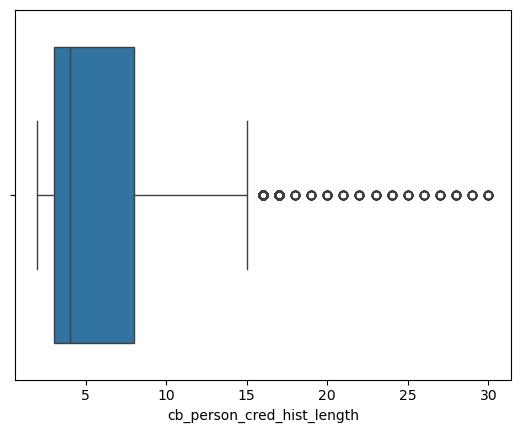

In [7]:
numerical_cols=df.select_dtypes(include=np.number).columns
for i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()




In [8]:
(df['person_age']>100).sum()

np.int64(5)

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [10]:
(df['person_emp_length']>60).sum()

np.int64(2)

Correlation check

See how strongly features are related to each other.

This helps us spot repeated or linked information.

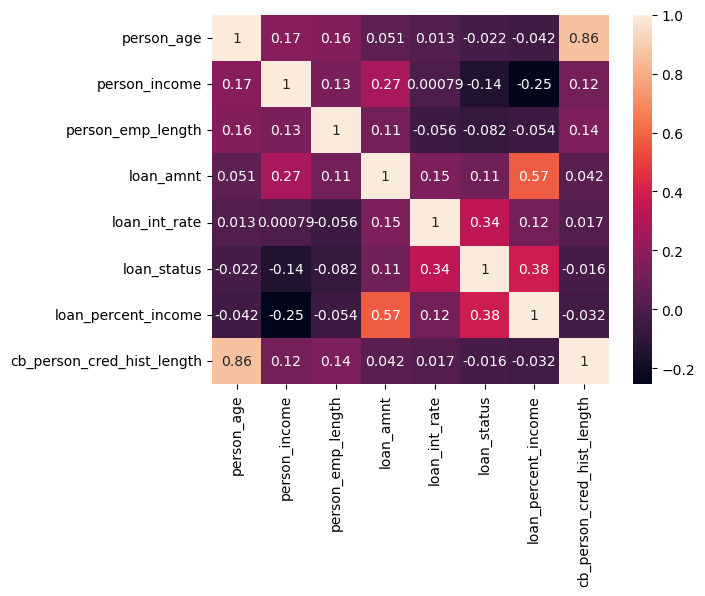

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()


3. Data Validation & Outlier Handling

Here we clean the data properly.

We remove duplicate rows.

We remove rows with an impossible age or work experience.

We remove rows with zero or negative income and loan amount.

We check if the interest rate looks realistic.

We also flag rows where numbers don't add up correctly.

In [12]:
df_copy=df.copy()

In [13]:
print(f"Original rows:{df_copy.shape[0]}")

Original rows:32581


In [14]:
### remove duplicate rows
df_copy.drop_duplicates(inplace=True)
print(f"rows after removing duplicates:{df_copy.shape[0]}")

rows after removing duplicates:32416


In [15]:
### remove age below 18 or 100
df_copy=df_copy[df_copy['person_age']>=18]
df_copy=df_copy[df_copy['person_age']<=100]

## remove employement length greater than age or extreme outliers (>60).
df_copy=df_copy[df_copy['person_emp_length']<=df_copy['person_age']]
df_copy=df_copy[df_copy['person_emp_length']<=60]


## remove the rows with zero or negative income and loan amount.
df_copy=df_copy[df_copy['loan_amnt']>0]

print("Loan interest rate range from (min:5.42 and max23.22)")

Loan interest rate range from (min:5.42 and max23.22)


4. Features, Target & Train-Test Split

We separate the data into input features and the target.

The target is whether the applicant defaulted or not.

We split the data into a training part and a testing part.

The model learns from the training part only.

In [16]:
X=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status'] ## 0,1

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y) 

In [18]:
X.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [19]:
numerical_cols=['person_age', 'person_income',
       'person_emp_length',  'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']

category_cols=['person_home_ownership','loan_grade','loan_intent','cb_person_cred_hist_length']


5. Handle Class Imbalance

Very few people actually default in this data.

If we ignore this, the model may just favor the majority class.

We give more importance to the minority class during training.

This helps the model actually learn to spot defaulters.

In [20]:
neg,pos=np.bincount(y_train)
scales_weight=neg/pos

In [21]:
scales_weight

np.float64(3.6312213039485766)

6. Data Preprocessing — Pipelines & Column Transformer

Raw data is not ready for a model directly.

We need to prepare numeric and text columns differently.

We will build a Pipeline for each model.

We will use ColumnTransformer to apply different steps to different columns.

**Preprocessing for Logistic Regression**

Fill missing numeric values.

Scale numeric values, since this model is sensitive to scale.

Convert category columns into numbers using one-hot encoding.

In [22]:
## logestic regression :

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder, LabelEncoder

preprocessor_lr=ColumnTransformer(
    transformers=[
        ## pipeline - for numerical columns 
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numerical_cols),
        ### pipeline - for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),category_cols)
    ]
)


Preprocessing for XGBoost


Fill missing numeric values.

No scaling needed here, since tree models don't need it.

Convert category columns into numbers using one-hot encoding.

In [23]:
#### XGBoost Pipeline : 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder, LabelEncoder
import xgboost as xgb

# Or import specific wrappers directly
from xgboost import XGBClassifier, XGBRegressor


preprocessor_xg=ColumnTransformer(
    transformers=[
        ## pipeline - for numerical columns 
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median'))
        ]),numerical_cols),
        ### pipeline - for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),category_cols)
    ]
)

7. Evaluation Helper Function

We build one common function to check any model's performance.

It will show accuracy, precision, recall, F1 score, and more.

It will also show a confusion matrix and a precision-recall curve.

In [24]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
## we have to evaluate logistic model and XGBoost model on  the basis of their metrics:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,classification_report

def evaluate_model(model_name,model,X_test,y_test,threshold=None):
    y_pred=model.predict(X_test)
    y_pred_prob=model.predict_proba(X_test)[:,1]

    if threshold:
        y_pred=(y_pred_prob>threshold).astype(int)
    else:
        y_pred=model.predict(X_test)

    ## Metrics:
    accuracy=accuracy_score(y_test,y_pred) ## overall model performance
    precision=precision_score(y_test,y_pred)## of the one I picked , how many were actally 
    recall=recall_score(y_test,y_pred) ## out of everything that was really there,how much did you manage to find?
    f1=f1_score(y_test,y_pred) ### Harmonic mean of  precision and recall

   

    ## Confusion matrix 

    cm = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)  # Fixed

    print(f"Best Threshold:{best_threshold}")
    print(f"Accuracy:{accuracy:.2f}") 
    print(f"Precision:{precision:.2f}") 
    print(f"Recall:{recall:.2f}") 
    print(f"f1:{f1:.2f}")
    print()

    print(f"{model_name} classification_report:")
    print(class_report)

    ## plotting Confusion Matrix

    sns.heatmap(cm,annot=True,fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()



    ## plotting ROC-AUC curve
    precision,recall,threshold=precision_recall_curve(y_test,y_pred_prob)

    plt.plot(recall,precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name}Precision-Recall-Curve")
    plt.show()
    

8. Stratified Cross-Validation

One single train-test split may not be reliable.

We split the training data into five folds instead.

Each fold keeps the same default vs repaid ratio.

We check the model's score across all folds.

In [25]:
from sklearn.model_selection import StratifiedKFold ,cross_validate
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring={'roc_auc':'roc_auc','accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1'}


In [26]:
### Logestic Regression :
from sklearn.linear_model import LogisticRegression 
lr_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced'))
])
lr_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
### XGBoost Model:

from xgboost import XGBClassifier

xgb_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(
        n_estimatior=300,max_depth=5,learning_rate=.1,
        scale_pos_weight=scales_weight,random_state=42
    ))
])

In [28]:
for cv_name, pipe in [("Logistic Regression", lr_cv_pipeline),
                      ("XGBoost", xgb_cv_pipeline)]:
    
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    print(f"--- {cv_name} ---")
    print(f"ROC-AUC:{cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy:{cv_results['test_accuracy'].mean()}")
    print(f"Precision:{cv_results['test_precision'].mean()}")
    print(f"Recall:{cv_results['test_recall'].mean()}")
    print(f"F1:{cv_results['test_f1'].mean()}")
    print()

--- Logistic Regression ---
ROC-AUC:0.8699987786803789
Accuracy:0.8105639714160049
Precision:0.54305823769498
Recall:0.7768595041322314
F1:0.6391626423399333

--- XGBoost ---
ROC-AUC:0.9386231936236149
Accuracy:0.9082759403153498
Precision:0.7901538981306364
Recall:0.784573002754821
F1:0.7869714720499765



9. Baseline Model — Logistic Regression

We start with a simple model first.

This becomes our benchmark to beat.

We train it and check its score on the test data.


In [29]:
baseline_model=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Best Threshold:None
Accuracy:0.82
Precision:0.56
Recall:0.79
f1:0.65

Baseline Logistic Model classification_report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.74      0.81      0.76      6305
weighted avg       0.85      0.82      0.83      6305



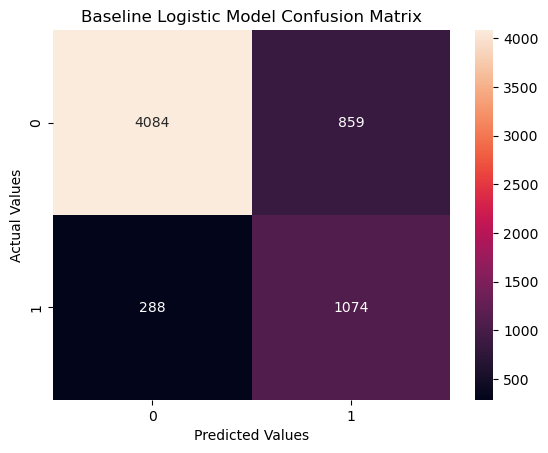

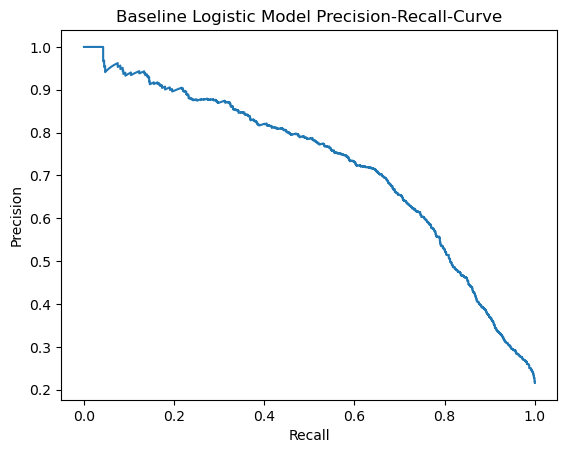

In [30]:
### evalute the logistic model 

def evaluate_model(model_name,model,X_test,y_test,threshold=None):
    from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,classification_report,precision_recall_curve
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    y_pred=model.predict(X_test)
    y_pred_prob=model.predict_proba(X_test)[:,1]

    if threshold:
        y_pred=(y_pred_prob>threshold).astype(int)
    else:
        y_pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision_val=precision_score(y_test,y_pred)
    recall_val=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"Best Threshold:{threshold}")
    print(f"Accuracy:{accuracy:.2f}") 
    print(f"Precision:{precision_val:.2f}") 
    print(f"Recall:{recall_val:.2f}") 
    print(f"f1:{f1:.2f}\n")
    print(f"{model_name} classification_report:\n{class_report}")
    
    sns.heatmap(cm,annot=True,fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.show()

    precision_curve,recall_curve,thresholds_curve=precision_recall_curve(y_test,y_pred_prob)
    plt.plot(recall_curve,precision_curve)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} Precision-Recall-Curve")
    plt.show()

# Now call the function with the fixed definition above
evaluate_model('Baseline Logistic Model',baseline_model,X_test,y_test)


10. XGBoost Hyperparameter Tuning

Now we move to a stronger model, XGBoost.

A model has many settings called hyperparameters.

We search for the best combination of these settings.

We use cross-validation while searching, so the result is reliable.

In [31]:
xg_model=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(
    n_estimator=300,
    max_depth=5,
    learning_rate=.1,
    scale_pos_weight=scales_weight,
    random_state=42
    ))
])
xg_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Best Threshold:None
Accuracy:0.91
Precision:0.79
Recall:0.79
f1:0.79

Baseline XBGoost Model classification_report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4943
           1       0.79      0.79      0.79      1362

    accuracy                           0.91      6305
   macro avg       0.87      0.87      0.87      6305
weighted avg       0.91      0.91      0.91      6305



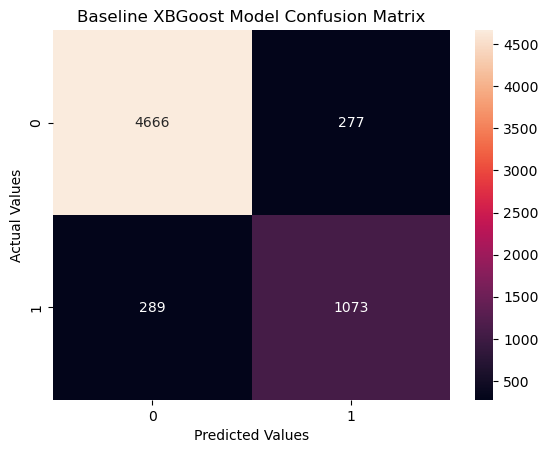

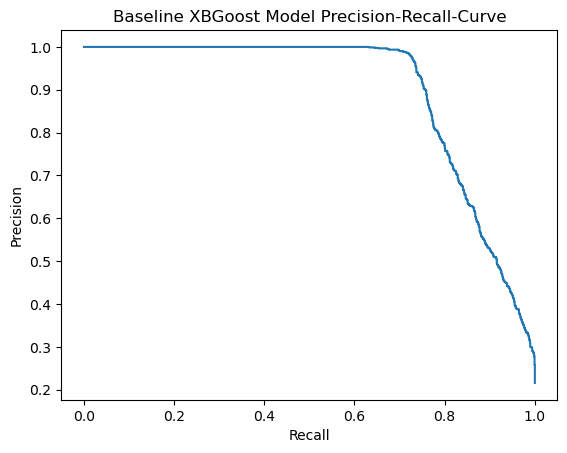

In [32]:
### evaluate  the xgboost 
evaluate_model('Baseline XBGoost Model',xg_model,X_test,y_test)

In [33]:

from scipy.stats import uniform,randint
from sklearn.model_selection import RandomizedSearchCV 
param_grid={
    "classifier__n_estimators":randint(150,600),
    "classifier__max_depth":randint(3,9),
    "classifier__learning_rate":uniform(0.01,0.5),
    "classifier__colsample_bytree":uniform(0.5,0.5),## Columns sampling 
    "classifier__subsample":uniform(0.6,0.4), ## Row Sampling
    "classifier__min_child_weight":randint(1,10),
    "classifier__gamma":uniform(0,5) ## control the uniform 

}


In [34]:
random_search=RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....t 0x15481e710>, 'classifier__gamma': <scipy.stats....t 0x154641f30>, 'classifier__learning_rate': <scipy.stats....t 0x1545c0d70>, 'classifier__max_depth': <scipy.stats....t 0x15481e350>, ...}"
,n_iter,150
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [35]:
print(f"Scoring after performing Tuning --> {random_search.best_score_:2f}")


Scoring after performing Tuning --> 0.901406


In [36]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.8883111758577285),
 'classifier__gamma': np.float64(1.3586588304857932),
 'classifier__learning_rate': np.float64(0.2623116099999353),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 1,
 'classifier__n_estimators': 466,
 'classifier__subsample': np.float64(0.96865457615669)}

11. Compare Both Models Side by Side

We now compare Logistic Regression and XGBoost.

We look at their scores together in one table.

This helps us pick the better performing model.


Best Threshold:None
Accuracy:0.92
Precision:0.81
Recall:0.81
f1:0.81

XGBoost classification_report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.81      0.81      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



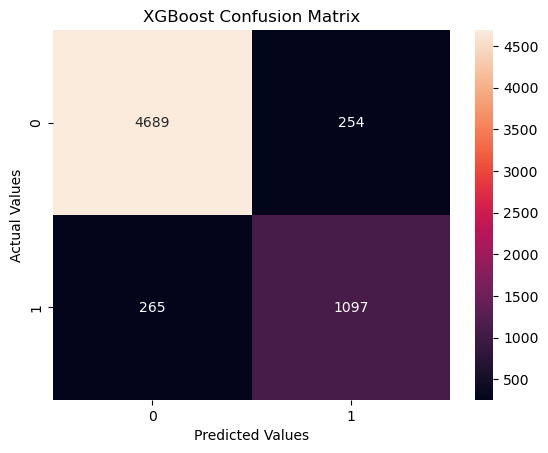

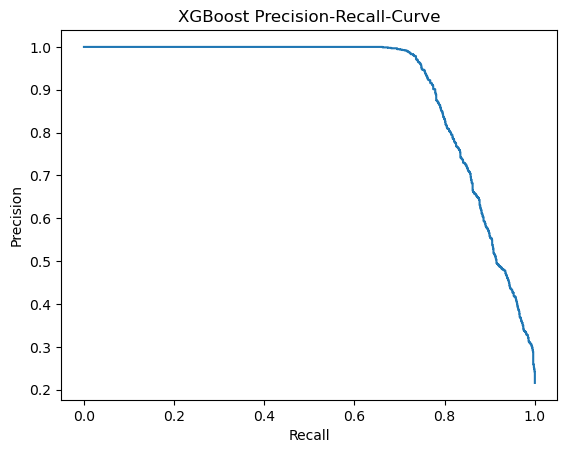

In [37]:
## passing the XGBoost model after performing  Hyperparameter Tuning.
evaluate_model("XGBoost",random_search,X_test,y_test)


12. Optimizing the Classification Threshold

The model gives a probability, not a direct yes or no.

We decide a cut-off point to turn it into a decision.

We check different cut-off points and pick the best one.

Best Threshold:0.7522053718566895
Accuracy:0.94
Precision:0.98
Recall:0.73
f1:0.83

XGBoost classification_report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      4943
           1       0.98      0.73      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



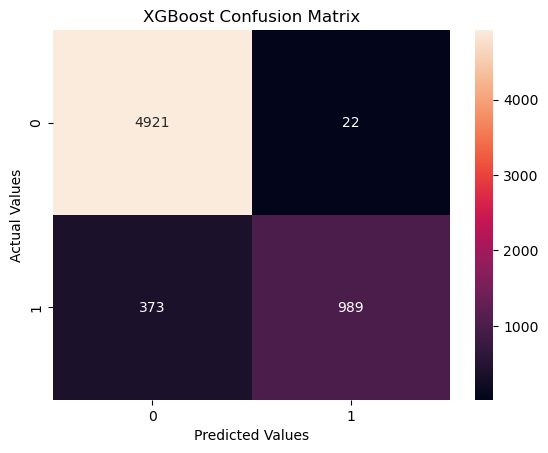

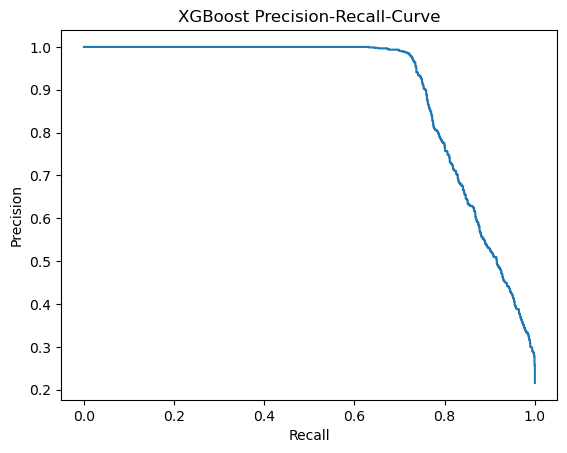

In [38]:
### get the prob. of class  1 from XGBoost.
prob=xg_model.predict_proba(X_test)[:,1]
prob

## for each threshold calculate precision and recall.
precision,recall,threshold=precision_recall_curve(y_test,prob)

### calculate F1 score for each threshold (FIXED: changed - to *)
f1=2*(precision*recall)/(precision+recall+1e-9)
f1

## get the threshold that produce the highest F1-score 
best=np.argmax(f1[:-1])
best_threshold=threshold[best]

## Evaluate the XGBoost model using that threshold.
evaluate_model("XGBoost",xg_model,X_test,y_test,best_threshold)


13. Probability Calibration

Sometimes a model's probability doesn't mean what it says.

For example, 30% risk should truly mean a 30% chance.

We check this with a calibration plot.

We fix it if the probabilities are off.

In [39]:
# """
# Method by which we can fix the poorly calibrated model.
# 1. platt scaling /Sigmoid -> adjust the probabilities using a sigmoid curve.
# 2. Isotonic Regression -> Learn a flexible mapping from old prob. - better probability(non-linear type).
# 3. temperature scaling -> adjust the confidence of neural-network prediction using one temperature. 
## """

In [40]:
### 1. calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
calibrated_model=CalibratedClassifierCV(
    xg_model,method="sigmoid",cv=5
)
calibrated_model.fit(X_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [41]:
## Get probabilities 

uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [42]:
### create calibration curves 

actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

In [43]:
actual_cal, predicted_cal  = calibration_curve(y_test, calibrated, n_bins=10)

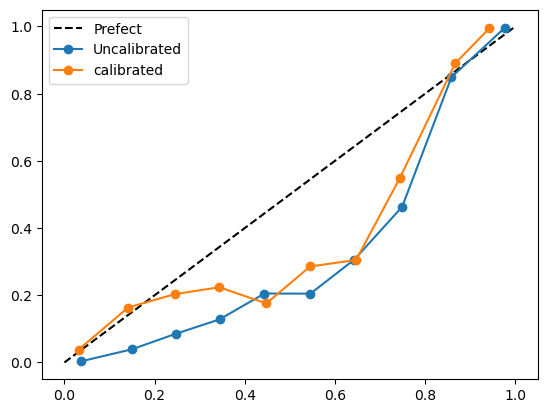

In [44]:
### plot
plt.plot([0,1],[0,1],'k--',label="Prefect")
plt.plot(
    predicted_uncal,
    actual_uncal,
    "o-",
    label="Uncalibrated"
)
plt.plot(
    predicted_cal,
    actual_cal,
    "o-",
    label="calibrated"
)
plt.legend()
plt.show()

14. SHAP Interpretation — Global & Local

SHAP helps us understand why the model makes a decision.

It is a way of explaining a "black box" model.

In [45]:
import shap

In [46]:
#2. Get the Trained XGBoost classifier model out of the pipeline.
xgb_classifier = xg_model.named_steps['classifier']

In [47]:
#3. Transform X_test using the same preprocessing used for training.
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [48]:
#4. Get feature names after one-hot enocding , so plots are readable
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [49]:
#5. Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed.toarray(), columns=feature_names)


In [50]:
explainer = shap.TreeExplainer(xgb_classifier)

# Now calculate the shap values
shap_values = explainer.shap_values(X_test_df)
shap_values


array([[-3.9525148e-02,  2.1065858e-01,  1.7049052e-01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 2.0294152e-01, -4.1207319e-01, -1.3651218e-01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-6.1225696e-03,  4.0642824e+00,  9.5757291e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       ...,
       [-3.5990499e-02,  4.2466396e-01, -8.7800428e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.6537566e-03, -5.1007819e-01, -1.8374654e-02, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.1046266e-01, -6.3967228e-01,  2.1772823e-01, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
      shape=(6305, 53), dtype=float32)

Global explanation

This shows which features matter most overall.

It also shows if a feature increases or decreases risk.

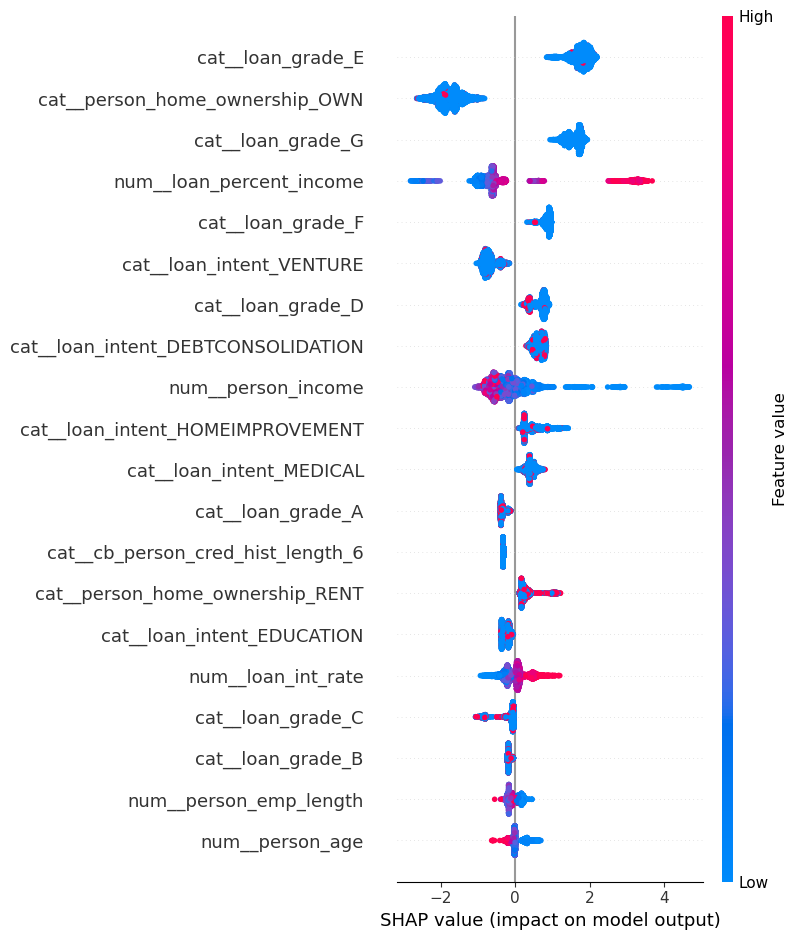

In [51]:
shap.summary_plot(shap_values, X_test_df)

Local explanation

This shows why one specific applicant got their score.

It breaks the score down feature by feature.

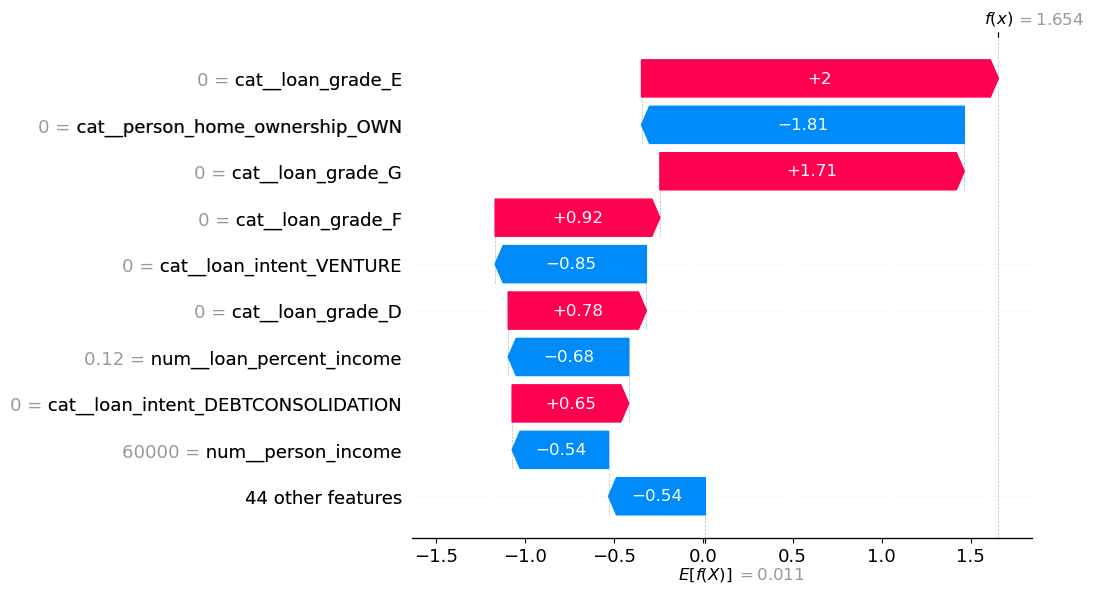

In [52]:
# 1. Pick one row to explain, e.g. the 5th applicant in the test set
row_index = 5

#2. Draw a waterfall plot showing how each feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

15. Analyzing False Positives & False Negatives

The model will not be perfect.

False positives are safe people wrongly marked risky.

False negatives are risky people wrongly marked safe.

We study these cases to understand where the model struggles.

In [53]:

#Get predictions from the best performing XGBoost model on the test set
y_pred = random_search.predict(X_test)

In [54]:
#Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [55]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [56]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")
     

False Positive : 254
False Negative : 265


16. Save the Final Model

Once we are happy with the model, we save it.

We also save the settings it needs, like the chosen threshold.

This saved file can now be used in a real application.

In [57]:
import joblib

joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [58]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']